<a href="https://colab.research.google.com/github/Mukunda-art/Future_ML_01/blob/main/Sales%26Demand_forecasting_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Performance
MAE: 98.26
RMSE: 118.46
R² Score: -0.02

Next 30 Days Forecast
   Order Date  Forecast Sales
0  2024-02-05      297.863657
1  2024-02-06      301.202943
2  2024-02-07      304.542229
3  2024-02-08      307.881514
4  2024-02-09      311.220800
5  2024-02-10      314.560086
6  2024-02-11      317.899371
7  2024-02-12      301.318757
8  2024-02-13      304.658043
9  2024-02-14      307.997329
10 2024-02-15      311.336614
11 2024-02-16      314.675900
12 2024-02-17      318.015186
13 2024-02-18      321.354471
14 2024-02-19      304.773857
15 2024-02-20      308.113143
16 2024-02-21      311.452429
17 2024-02-22      314.791714
18 2024-02-23      318.131000
19 2024-02-24      321.470286
20 2024-02-25      324.809571
21 2024-02-26      308.228957
22 2024-02-27      311.568243
23 2024-02-28      314.907529
24 2024-02-29      318.246814
25 2024-03-01      307.272114
26 2024-03-02      310.611400
27 2024-03-03      313.950686
28 2024-03-04      297.370071
29 2024-03-05      

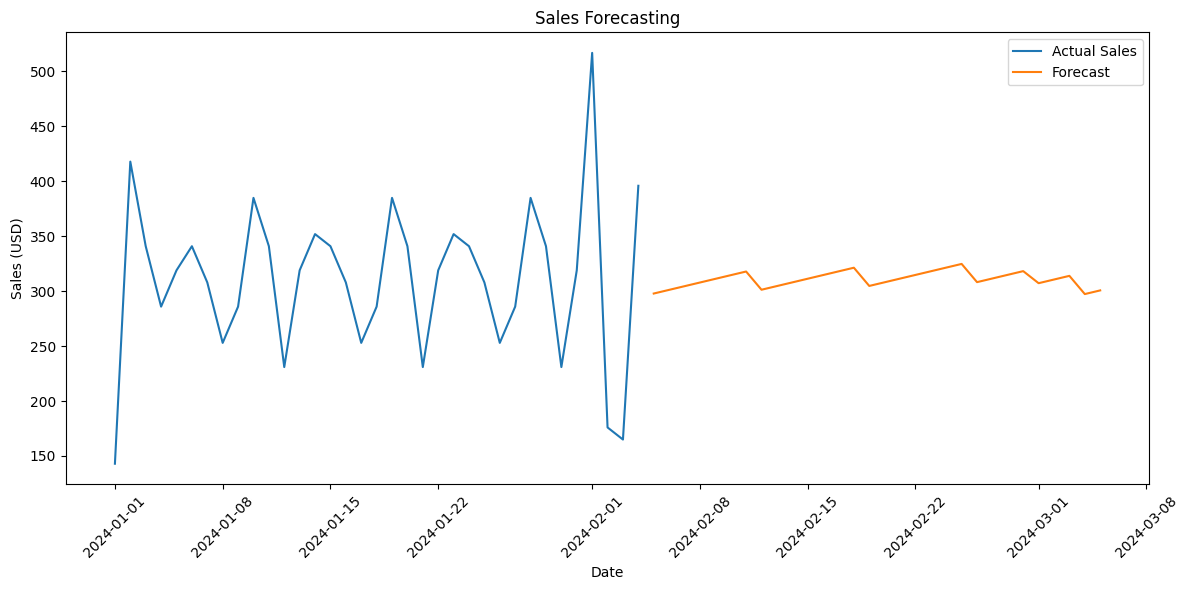

In [3]:
# Sales & Demand Forecasting for Businesses
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
file_path = "sales_dataset (1).xlsx"
# Read correct header position
df = pd.read_excel(file_path, header=7)
df = df.drop(columns=["Unnamed:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df = df.dropna()
sales = (
    df.groupby("Order Date")["Total (USD)"]
    .sum()
    .reset_index()
)

# ==========================
# Feature Engineering
# ==========================
sales["Day"] = sales["Order Date"].dt.day
sales["Month"] = sales["Order Date"].dt.month
sales["Year"] = sales["Order Date"].dt.year
sales["DayOfWeek"] = sales["Order Date"].dt.dayofweek

X = sales[["Day", "Month", "Year", "DayOfWeek"]]
y = sales["Total (USD)"]

# ==========================
# Train Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# ==========================
# Model Training
# ==========================
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# ==========================
# Evaluation
# ==========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Model Performance")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

# ==========================
# Forecast Next 30 Days
# ==========================
future_dates = pd.date_range(
    start=sales["Order Date"].max(),
    periods=31,
    freq="D"
)[1:]

future = pd.DataFrame({
    "Order Date": future_dates
})

future["Day"] = future["Order Date"].dt.day
future["Month"] = future["Order Date"].dt.month
future["Year"] = future["Order Date"].dt.year
future["DayOfWeek"] = future["Order Date"].dt.dayofweek

future["Forecast Sales"] = model.predict(
    future[["Day", "Month", "Year", "DayOfWeek"]]
)

print("\nNext 30 Days Forecast")
print(future[["Order Date", "Forecast Sales"]])

# ==========================
# Visualization
# ==========================
plt.figure(figsize=(12,6))

plt.plot(
    sales["Order Date"],
    sales["Total (USD)"],
    label="Actual Sales"
)

plt.plot(
    future["Order Date"],
    future["Forecast Sales"],
    label="Forecast"
)

plt.title("Sales Forecasting")
plt.xlabel("Date")
plt.ylabel("Sales (USD)")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()